Amardeep Singh

E23CSEU2189

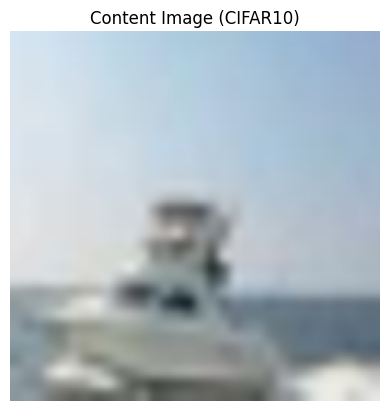

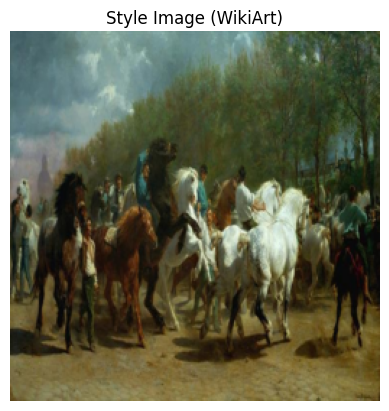

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 173MB/s]


Step: 0 Loss: 5873502.0
Step: 50 Loss: 367362.0
Step: 100 Loss: 217917.609375
Step: 150 Loss: 169876.453125
Step: 200 Loss: 142909.0625
Step: 250 Loss: 124579.484375


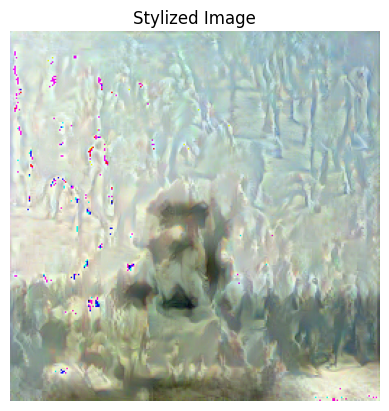

In [2]:
# ======================================
# CSET419 – Lab 7
# Neural Style Transfer using VGG19
# Content: CIFAR-10
# Style: WikiArt
# ======================================

import torch
import torch.optim as optim
from torchvision import models, transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------
# Image size
# --------------------------------------

image_size = 256

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# --------------------------------------
# Load CIFAR-10 Content Image
# --------------------------------------

cifar = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True
)

content_img, label = cifar[100]   # choose index

content_img = content_img.resize((256,256), Image.BICUBIC)

content_img = transforms.ToTensor()(content_img).unsqueeze(0).to(device)

# --------------------------------------
# Load WikiArt Style Image
# --------------------------------------

style_path = "wikiart_style.jpg"   # place style image in folder

style_img = Image.open(style_path).convert("RGB")

style_img = transform(style_img).unsqueeze(0).to(device)

# --------------------------------------
# Display Images
# --------------------------------------

def show(img, title):

    img = img.clone().cpu().squeeze(0)
    img = transforms.ToPILImage()(img)

    plt.imshow(img)
    plt.title(title)
    plt.axis("off")
    plt.show()

show(content_img,"Content Image (CIFAR10)")
show(style_img,"Style Image (WikiArt)")

# --------------------------------------
# Load Pretrained VGG19
# --------------------------------------

vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

# --------------------------------------
# Feature Extraction
# --------------------------------------

def get_features(image, model):

    layers = {
        '0':'conv1_1',
        '5':'conv2_1',
        '10':'conv3_1',
        '19':'conv4_1',
        '21':'conv4_2',
        '28':'conv5_1'
    }

    features = {}
    x = image

    for name, layer in model._modules.items():

        x = layer(x)

        if name in layers:
            features[layers[name]] = x

    return features

# --------------------------------------
# Gram Matrix (Style Representation)
# --------------------------------------

def gram_matrix(tensor):

    b, c, h, w = tensor.size()

    tensor = tensor.view(c, h*w)

    gram = torch.mm(tensor, tensor.t())

    return gram

# --------------------------------------
# Extract Features
# --------------------------------------

content_features = get_features(content_img, vgg)
style_features = get_features(style_img, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

# --------------------------------------
# Generated Image
# --------------------------------------

generated = content_img.clone().requires_grad_(True).to(device)

# --------------------------------------
# Loss Weights
# --------------------------------------

style_weight = 1e6
content_weight = 1

optimizer = optim.Adam([generated], lr=0.003)

# --------------------------------------
# Training Loop
# --------------------------------------

steps = 300

style_layers = ['conv1_1','conv2_1','conv3_1','conv4_1','conv5_1']

for step in range(steps):

    gen_features = get_features(generated, vgg)

    content_loss = torch.mean(
        (gen_features['conv4_2'] - content_features['conv4_2'])**2
    )

    style_loss = 0

    for layer in style_layers:

        gen_feature = gen_features[layer]

        gen_gram = gram_matrix(gen_feature)

        style_gram = style_grams[layer]

        _, c, h, w = gen_feature.shape

        style_loss += torch.mean((gen_gram - style_gram)**2)/(c*h*w)

    total_loss = content_weight*content_loss + style_weight*style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if step % 50 == 0:
        print("Step:", step, "Loss:", total_loss.item())

# --------------------------------------
# Show Final Stylized Image
# --------------------------------------

show(generated,"Stylized Image")